In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer # Necesario para usar skl_imp, no borrar
from src.preprocessing import *

In [2]:
# Abrir archivo raw_data
data_folder = "data"
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17947 entries, 0 to 17946
Data columns (total 37 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                17947 non-null  object 
 1   Close               17947 non-null  float64
 2   Ticker              17947 non-null  object 
 3   Monthly_Return      17475 non-null  float64
 4   Monthly_Variance    17475 non-null  float64
 5   Market_Covariance   17475 non-null  float64
 6   MarketCap           17896 non-null  float64
 7   EnterpriseValue     17896 non-null  float64
 8   PE_Trailing         17857 non-null  float64
 9   EnterpriseToEbitda  17896 non-null  float64
 10  PriceToBook         17857 non-null  float64
 11  operatingMargins    17947 non-null  float64
 12  profitMargins       17908 non-null  float64
 13  returnOnEquity      17869 non-null  float64
 14  ReturnOnAssets      17908 non-null  float64
 15  debtToEquity        17908 non-null  float64
 16  curr

In [3]:
columnas_a_eliminar = ['Close']
df.drop(columnas_a_eliminar, axis=1, inplace=True)

# Formatear market cap y EnterpriseValue en billions
df["MarketCap"] = df["MarketCap"] / 10**9
df["EnterpriseValue"] = df["EnterpriseValue"] / 10**9

# Variables continuas

In [4]:
# Distribucion de variables continuas
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Monthly_Return,17475.0,0.01,0.10,-0.52,-0.04,0.01,0.06,1.43
Monthly_Variance,17475.0,0.01,0.01,0.00,0.00,0.01,0.01,0.37
Market_Covariance,17475.0,0.00,0.00,-0.00,0.00,0.00,0.00,0.02
MarketCap,17896.0,108.16,349.16,0.70,18.19,35.00,76.85,5137.17
EnterpriseValue,17896.0,120.25,353.60,3.16,22.76,43.67,90.69,5137.61
PE_Trailing,17857.0,-15.85,1989.51,-101202.95,15.54,24.26,36.27,5658.65
EnterpriseToEbitda,17896.0,20.73,64.40,-1813.33,11.08,15.76,21.94,1311.66
PriceToBook,17857.0,6.86,52.73,-1113.18,1.87,3.73,8.04,1353.06
operatingMargins,17947.0,0.19,0.15,-1.60,0.11,0.18,0.26,0.93
profitMargins,17908.0,0.13,0.16,-1.72,0.07,0.12,0.20,1.04


In [5]:
# Coeficientes de asimetria
df.select_dtypes(include="number").skew()

Monthly_Return         1.493648
Monthly_Variance      12.043219
Market_Covariance      1.348368
MarketCap              8.249117
EnterpriseValue        8.111495
PE_Trailing          -39.283630
EnterpriseToEbitda    -1.985330
PriceToBook            6.933158
operatingMargins      -0.444976
profitMargins         -1.909061
returnOnEquity         0.730212
ReturnOnAssets         0.711351
debtToEquity          -4.313670
currentRatio           6.742593
Revenue_Growth_YoY     3.585476
Revenue_Growth_QoQ     8.093254
EBITDA_Growth_YoY    -11.988189
EBITDA_Growth_QoQ    -24.828236
FedFundsRate          -0.717675
10YTreasuryYield      -0.710855
YieldCurveSpread      -0.234896
UnemploymentRate      -0.341498
AAACorporateYield     -0.606688
USDollarIndex          0.264847
HighYieldSpread        0.912784
CPI_QoQ                0.655288
M2_QoQ                -1.441863
INDPRO_QoQ             0.048588
CPI_YoY                0.254275
M2_YoY                -0.796841
INDPRO_YoY             0.013452
dtype: f

Cont


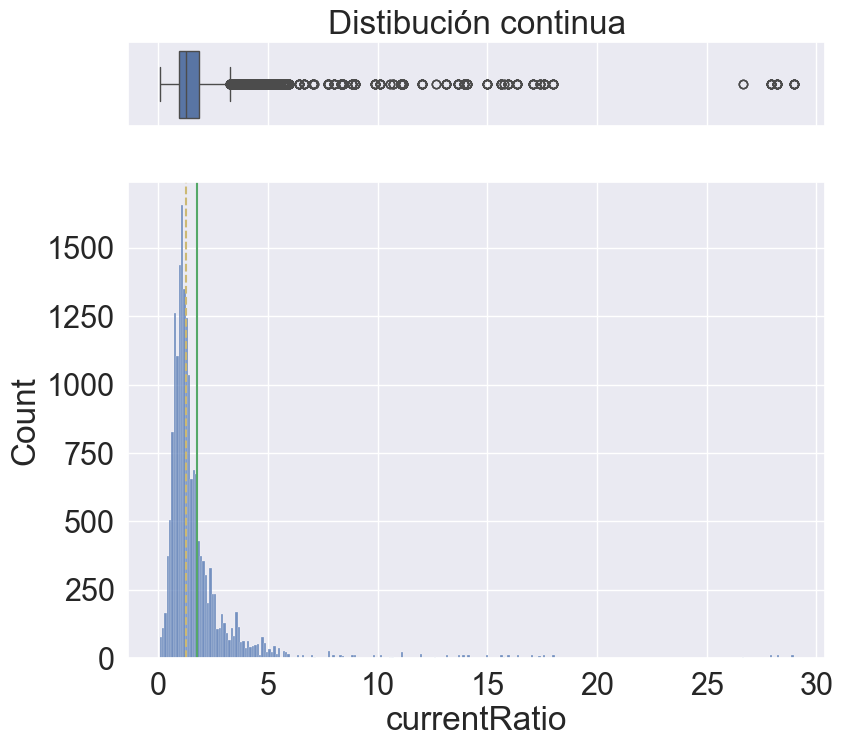

In [6]:
# Graficar
columna_a_graficar = 'currentRatio' # indicar columna para el grafico
plot(df[columna_a_graficar])

In [7]:
# Transformacion yeo-johnson
pt = PowerTransformer(method='yeo-johnson', standardize=True)
columnas_a_transformar = ['PriceToBook', 'returnOnEquity', 'PE_Trailing', 'EnterpriseToEbitda']
for columna in columnas_a_transformar:
    df[f'{columna}_Transformed'] = pt.fit_transform(df[[columna]])
    # Elimino la columna sin transformar
    df.drop(columna, axis=1, inplace=True)

In [8]:
# Transformaciones logarítmicas
columnas_a_transformar = ['MarketCap', 'EnterpriseValue', 'debtToEquity', 'currentRatio']
for columna in columnas_a_transformar:
    df[f'{columna}_log'] = np.log1p(df[columna])
    df.drop(columna, axis=1, inplace=True)

# Coeficientes de asimetria actualizado
df.select_dtypes(include="number").skew()

c:\Users\sebas\anaconda3\envs\ucm-dev\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Monthly_Return                     1.493648
Monthly_Variance                  12.043219
Market_Covariance                  1.348368
operatingMargins                  -0.444976
profitMargins                     -1.909061
ReturnOnAssets                     0.711351
Revenue_Growth_YoY                 3.585476
Revenue_Growth_QoQ                 8.093254
EBITDA_Growth_YoY                -11.988189
EBITDA_Growth_QoQ                -24.828236
FedFundsRate                      -0.717675
10YTreasuryYield                  -0.710855
YieldCurveSpread                  -0.234896
UnemploymentRate                  -0.341498
AAACorporateYield                 -0.606688
USDollarIndex                      0.264847
HighYieldSpread                    0.912784
CPI_QoQ                            0.655288
M2_QoQ                            -1.441863
INDPRO_QoQ                         0.048588
CPI_YoY                            0.254275
M2_YoY                            -0.796841
INDPRO_YoY                      

## Gestion de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [9]:
# Outliers
df_cont = df.select_dtypes(include="number")
df_winsor = df_cont.apply(lambda x: gestiona_outliers(x, clas='winsor'))

Monthly_Return
Monthly_Variance
Market_Covariance
operatingMargins
profitMargins
ReturnOnAssets
Revenue_Growth_YoY
Revenue_Growth_QoQ
EBITDA_Growth_YoY
EBITDA_Growth_QoQ
FedFundsRate
10YTreasuryYield
YieldCurveSpread
UnemploymentRate
AAACorporateYield
USDollarIndex
HighYieldSpread
CPI_QoQ
M2_QoQ
INDPRO_QoQ
CPI_YoY
M2_YoY
INDPRO_YoY
PriceToBook_Transformed
returnOnEquity_Transformed
PE_Trailing_Transformed
EnterpriseToEbitda_Transformed
MarketCap_log
EnterpriseValue_log
debtToEquity_log
currentRatio_log


In [10]:
# Coeficientes de asimetria actualizados luego de winsorizar
df_winsor.skew()

Monthly_Return                    0.446946
Monthly_Variance                  1.757930
Market_Covariance                 1.042230
operatingMargins                  0.528602
profitMargins                     0.148774
ReturnOnAssets                    0.576475
Revenue_Growth_YoY                0.210198
Revenue_Growth_QoQ               -2.258225
EBITDA_Growth_YoY                 0.461847
EBITDA_Growth_QoQ                -0.500959
FedFundsRate                     -0.717675
10YTreasuryYield                 -0.710855
YieldCurveSpread                 -0.234896
UnemploymentRate                 -0.341498
AAACorporateYield                -0.606688
USDollarIndex                     0.264847
HighYieldSpread                   0.912784
CPI_QoQ                           0.655288
M2_QoQ                           -1.441863
INDPRO_QoQ                        0.048588
CPI_YoY                           0.254275
M2_YoY                           -0.796841
INDPRO_YoY                        0.013452
PriceToBook

Cont


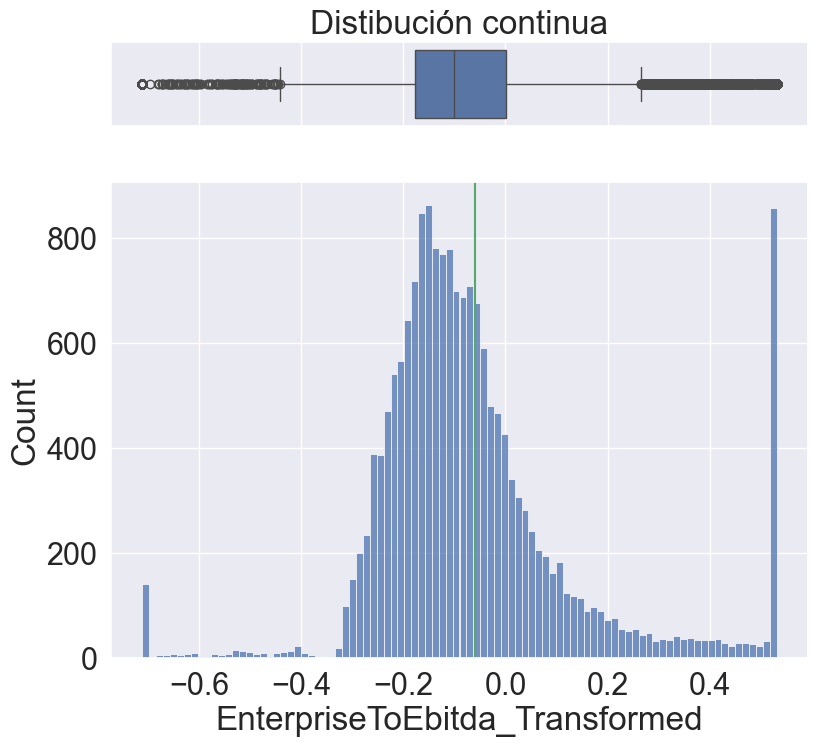

In [11]:
# Visualizar cambios
columna_a_graficar = 'EnterpriseToEbitda_Transformed' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [12]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Return,17475.0,1.342738e-02,0.089829,-0.356837,-0.041374,0.010943,0.062653,0.375544
Monthly_Variance,17475.0,7.781231e-03,0.006182,0.000622,0.003580,0.005845,0.009752,0.028271
Market_Covariance,17475.0,1.635546e-03,0.001496,-0.003955,0.000617,0.001374,0.002405,0.007783
operatingMargins,17947.0,1.922924e-01,0.140256,-0.359800,0.106700,0.178200,0.261500,0.741900
profitMargins,17908.0,1.363131e-01,0.129939,-0.353200,0.067500,0.121600,0.197900,0.603100
ReturnOnAssets,17908.0,7.954659e-02,0.077155,-0.227700,0.033100,0.063600,0.117600,0.388700
Revenue_Growth_YoY,12522.0,5.196778e-02,0.126975,-0.328167,-0.002960,0.047863,0.104292,0.439850
Revenue_Growth_QoQ,16588.0,1.712046e-07,0.000016,-0.000056,0.000000,0.000000,0.000000,0.000020
EBITDA_Growth_YoY,12522.0,1.018124e-01,0.353149,-0.836414,-0.048352,0.075304,0.213284,1.002287
EBITDA_Growth_QoQ,16588.0,1.335891e-05,0.000130,-0.000320,0.000000,0.000000,0.000000,0.000237


# Variables Categoricas

In [13]:
df_non_numeric = df.select_dtypes(exclude='number')

In [14]:
# Valores unicos
df_non_numeric.nunique()

Date            48
Ticker         453
Sector          11
SubIndustry    119
DateAdded      337
dtype: int64

In [15]:
# Convertir Sector y SubIndustrya category
df_non_numeric['Sector'] = df_non_numeric['Sector'].astype('category')
df_non_numeric['SubIndustry'] = df_non_numeric['SubIndustry'].astype('category')

# Valores unicos en Sector
df_non_numeric['Sector'].value_counts()

Sector
Industrials              3123
InformationTechnology    2789
HealthCare               2200
ConsumerDiscretionary    1900
ConsumerStaples          1477
Financials               1268
RealEstate               1209
Utilities                1174
Materials                1025
CommunicationServices     925
Energy                    857
Name: count, dtype: int64

In [16]:
# Valores unicos en SubIndustry
df_non_numeric['SubIndustry'].value_counts()

SubIndustry
HealthCareEquipment                        642
ElectricUtilities                          585
Semiconductors                             562
IndustrialMachinery&Supplies&Components    556
ApplicationSoftware                        531
                                          ... 
FoodRetail                                  38
HomefurnishingRetail                        38
Footwear                                    37
HeavyElectricalEquipment                    15
HealthCareTechnology                        15
Name: count, Length: 119, dtype: int64

In [17]:
df_non_numeric[df_non_numeric['Sector'].isnull()]

,Date,Ticker,Sector,SubIndustry,DateAdded


In [18]:
# Transformar DateAdded a datetime y convertir a YearsSinceAdded
df_non_numeric['DateAdded'] = pd.to_datetime(df_non_numeric['DateAdded'], errors='coerce')
df_non_numeric['YearsSinceAdded'] = round(((pd.Timestamp.now() - df_non_numeric['DateAdded']).dt.days / 365.25), 0)
df_non_numeric.drop('DateAdded', axis=1, inplace=True)

In [19]:
# Merge de variables continuas transformadas y variables no numericas
df_combined = pd.concat([df_non_numeric, df_winsor], axis=1)
df_combined.head()

,Date,Ticker,Sector,SubIndustry,YearsSinceAdded,Monthly_Return,Monthly_Variance,Market_Covariance,operatingMargins,profitMargins,...,M2_YoY,INDPRO_YoY,PriceToBook_Transformed,returnOnEquity_Transformed,PE_Trailing_Transformed,EnterpriseToEbitda_Transformed,MarketCap_log,EnterpriseValue_log,debtToEquity_log,currentRatio_log
0,2023-01-01,A,HealthCare,LifeSciencesTools&Services,26.0,NaN,NaN,NaN,0.2363,0.1831,...,NaN,NaN,0.038194,0.013593,-0.035561,0.037309,3.814930,3.852051,0.420025,1.108596
1,2023-02-01,A,HealthCare,LifeSciencesTools&Services,26.0,NaN,NaN,NaN,0.2363,0.1831,...,NaN,NaN,0.027708,0.013593,-0.041881,0.011769,3.747707,3.787359,0.420025,1.108596
2,2023-03-01,A,HealthCare,LifeSciencesTools&Services,26.0,NaN,NaN,NaN,0.2363,0.1831,...,NaN,NaN,0.023942,0.013593,-0.044132,0.002614,3.722424,3.763071,0.420025,1.108596
3,2023-04-01,A,HealthCare,LifeSciencesTools&Services,26.0,-0.021035,0.005672,0.003620,0.2363,0.1831,...,NaN,NaN,0.020920,0.013593,-0.045929,-0.004718,3.701683,3.743165,0.420025,1.108596
4,2023-05-01,A,HealthCare,LifeSciencesTools&Services,26.0,-0.144514,0.007249,0.003212,0.2363,0.1831,...,NaN,NaN,0.000585,0.013593,-0.057844,-0.053877,3.549759,3.597885,0.420025,1.108596


# Missings

In [20]:
df_combined.isnull().sum()

Date                                 0
Ticker                               0
Sector                               0
SubIndustry                          0
YearsSinceAdded                      0
Monthly_Return                     472
Monthly_Variance                   472
Market_Covariance                  472
operatingMargins                     0
profitMargins                       39
ReturnOnAssets                      39
Revenue_Growth_YoY                5425
Revenue_Growth_QoQ                1359
EBITDA_Growth_YoY                 5425
EBITDA_Growth_QoQ                 1359
FedFundsRate                         3
10YTreasuryYield                     3
YieldCurveSpread                     3
UnemploymentRate                   455
AAACorporateYield                    3
USDollarIndex                        3
HighYieldSpread                   2204
CPI_QoQ                            994
M2_QoQ                              90
INDPRO_QoQ                          90
CPI_YoY                  

In [21]:
# Resto de las continuas: imputar multivariable con IterativeImputer
df_cont = df_combined.select_dtypes(include='number')
# Imputador: Chain equations
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

In [22]:
df_imputed = pd.DataFrame(imputer_itImp.fit_transform(df_cont),columns=df_cont.columns)
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17947 entries, 0 to 17946
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   YearsSinceAdded                 17947 non-null  float64
 1   Monthly_Return                  17947 non-null  float64
 2   Monthly_Variance                17947 non-null  float64
 3   Market_Covariance               17947 non-null  float64
 4   operatingMargins                17947 non-null  float64
 5   profitMargins                   17947 non-null  float64
 6   ReturnOnAssets                  17947 non-null  float64
 7   Revenue_Growth_YoY              17947 non-null  float64
 8   Revenue_Growth_QoQ              17947 non-null  float64
 9   EBITDA_Growth_YoY               17947 non-null  float64
 10  EBITDA_Growth_QoQ               17947 non-null  float64
 11  FedFundsRate                    17947 non-null  float64
 12  10YTreasuryYield                

In [23]:
df_final = pd.concat([df_imputed, df_combined.select_dtypes(exclude='number')], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17947 entries, 0 to 17946
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   YearsSinceAdded                 17947 non-null  float64 
 1   Monthly_Return                  17947 non-null  float64 
 2   Monthly_Variance                17947 non-null  float64 
 3   Market_Covariance               17947 non-null  float64 
 4   operatingMargins                17947 non-null  float64 
 5   profitMargins                   17947 non-null  float64 
 6   ReturnOnAssets                  17947 non-null  float64 
 7   Revenue_Growth_YoY              17947 non-null  float64 
 8   Revenue_Growth_QoQ              17947 non-null  float64 
 9   EBITDA_Growth_YoY               17947 non-null  float64 
 10  EBITDA_Growth_QoQ               17947 non-null  float64 
 11  FedFundsRate                    17947 non-null  float64 
 12  10YTreasuryYield  

In [24]:
df_final.select_dtypes(include='number').skew()

YearsSinceAdded                   1.033801
Monthly_Return                    0.479227
Monthly_Variance                  1.734374
Market_Covariance                 0.959614
operatingMargins                  0.528602
profitMargins                     0.144527
ReturnOnAssets                    0.571297
Revenue_Growth_YoY                0.154256
Revenue_Growth_QoQ               -2.353377
EBITDA_Growth_YoY                 0.553339
EBITDA_Growth_QoQ                -0.496166
FedFundsRate                     -0.717731
10YTreasuryYield                 -0.710914
YieldCurveSpread                 -0.234913
UnemploymentRate                 -0.375171
AAACorporateYield                -0.606738
USDollarIndex                     0.264865
HighYieldSpread                   1.272449
CPI_QoQ                           0.682261
M2_QoQ                           -1.415444
INDPRO_QoQ                        0.043679
CPI_YoY                           0.089602
M2_YoY                           -0.742718
INDPRO_YoY 

In [25]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")